In [310]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

## 1. Data Loading and Merging

In [311]:
factsales = pd.read_csv('Tables/factsales.csv')
factsales.head()

,SalesID,OrderID,ProductID,CustomerID,DateID,GeographyID,Sales,Quantity,Discount,Profit,Market,ShipMode,Discount Category
0,1200,CA-2011-169642,OFF-ST-10002574,BB-10990,447,27,276.28,2,0.0,0.0,US,Second Class,Non-Discounted
1,1486,CA-2012-142993,OFF-ST-10000934,KA-16525,555,48,81.96,2,0.0,0.0,US,Standard Class,Non-Discounted
2,1501,CA-2012-130736,OFF-FA-10003467,JF-15490,705,48,3.96,2,0.0,0.0,US,First Class,Non-Discounted
3,2167,CA-2011-136567,OFF-ST-10004337,PS-19045,17,105,122.48,2,0.0,0.0,US,First Class,Non-Discounted
4,5202,AG-2011-4560,FUR-DEF-10000572,EG-3900,17,805,103.92,2,0.0,0.0,Africa,Standard Class,Non-Discounted


In [312]:
dimproduct = pd.read_csv('Tables/dimproduct.csv')
dimproduct.head()

,ProductID,ProductName,Category,SubCategory
0,OFF-EAT-10000522,"Eaton Computer Printout Paper, Multicolor",Office Supplies,Paper
1,OFF-EAT-10000652,"Eaton Computer Printout Paper, 8.5 x 11",Office Supplies,Paper
2,OFF-EAT-10000820,"Eaton Message Books, Multicolor",Office Supplies,Paper
3,OFF-EAT-10000854,"Eaton Parchment Paper, Recycled",Office Supplies,Paper
4,OFF-EAT-10001025,"Eaton Note Cards, Multicolor",Office Supplies,Paper


In [313]:
dimgeography = pd.read_csv('Tables/dimgeograohy.csv')
dimgeography.head()

,GeographyID,City,State,Country,Region
0,78,Paris,Ile-de-France,United States,Central
1,84,Boulogne-Billancourt,Ile-de-France,United States,Central
2,85,Malakoff,Ile-de-France,United States,Central
3,103,Chelles,Ile-de-France,United States,Central
4,142,Argenteuil,Ile-de-France,United States,Central


In [314]:
dimorder = pd.read_csv('Tables/order.csv')
dimorder.rename(columns=lambda x: x.replace(" ", ""), inplace=True)
dimorder.head()

,OrderID,CustomerID,OrderPriority,OrderDate,Market
0,ID-2011-11126,AP-10720,Medium,2011-11-25 00:00:00.000,APAC
1,ID-2011-11385,TH-21100,Medium,2011-08-05 00:00:00.000,APAC
2,ID-2011-12596,CM-12235,Medium,2011-01-03 00:00:00.000,APAC
3,ID-2011-13114,DB-13060,Medium,2011-12-14 00:00:00.000,APAC
4,ID-2011-13170,AG-10525,Medium,2011-12-15 00:00:00.000,APAC


In [315]:
dimship = pd.read_csv('Tables/shipping.csv')
dimship.rename(columns=lambda x: x.replace(" ", ""), inplace=True)
dimship.head()

,ShippingID,OrderID,ShipDate,ShipMode,City,State,Country,Region
0,21150,CA-2012-149846,2012-05-26 00:00:00.000,Standard Class,Los Angeles,California,United States,West
1,21257,CA-2014-133865,2014-05-13 00:00:00.000,Standard Class,Los Angeles,California,United States,West
2,21374,CA-2013-107104,2013-12-01 00:00:00.000,Standard Class,Los Angeles,California,United States,West
3,21586,US-2013-126452,2013-08-29 00:00:00.000,Standard Class,Los Angeles,California,United States,West
4,22031,CA-2012-135580,2013-01-03 00:00:00.000,Standard Class,Los Angeles,California,United States,West


In [316]:
# Merge the fact and dimension tables on common keys
df_merged = factsales.merge(dimproduct, on='ProductID', how='left') \
                     .merge(dimgeography, on='GeographyID', how='left')

df_merged.head()

,SalesID,OrderID,ProductID,CustomerID,DateID,GeographyID,Sales,Quantity,Discount,Profit,Market,ShipMode,Discount Category,ProductName,Category,SubCategory,City,State,Country,Region
0,1200,CA-2011-169642,OFF-ST-10002574,BB-10990,447,27,276.28,2,0.0,0.0,US,Second Class,Non-Discounted,"SAFCO Commercial Wire Shelving, Black",Office Supplies,Storage,Los Angeles,California,United States,West
1,1486,CA-2012-142993,OFF-ST-10000934,KA-16525,555,48,81.96,2,0.0,0.0,US,Standard Class,Non-Discounted,"Contico 72""H Heavy-Duty Storage System",Office Supplies,Storage,Seattle,Washington,United States,West
2,1501,CA-2012-130736,OFF-FA-10003467,JF-15490,705,48,3.96,2,0.0,0.0,US,First Class,Non-Discounted,"Alliance Big Bands Rubber Bands, 12/Pack",Office Supplies,Fasteners,Seattle,Washington,United States,West
3,2167,CA-2011-136567,OFF-ST-10004337,PS-19045,17,105,122.48,2,0.0,0.0,US,First Class,Non-Discounted,"SAFCO Commercial Wire Shelving, 72h",Office Supplies,Storage,Harrisonburg,Virginia,United States,South
4,5202,AG-2011-4560,FUR-DEF-10000572,EG-3900,17,805,103.92,2,0.0,0.0,Africa,Standard Class,Non-Discounted,"Deflect-O Photo Frame, Duo Pack",Furniture,Furnishings,Annaba,Annaba,United States,Africa


## 2. Data Cleaning and Outlier Removal

In [317]:
# Check for missing values
df_merged.isna().sum()

SalesID              0
OrderID              0
ProductID            0
CustomerID           0
DateID               0
GeographyID          0
Sales                0
Quantity             0
Discount             0
Profit               0
Market               0
ShipMode             0
Discount Category    0
ProductName          0
Category             0
SubCategory          0
City                 0
State                0
Country              0
Region               0
dtype: int64

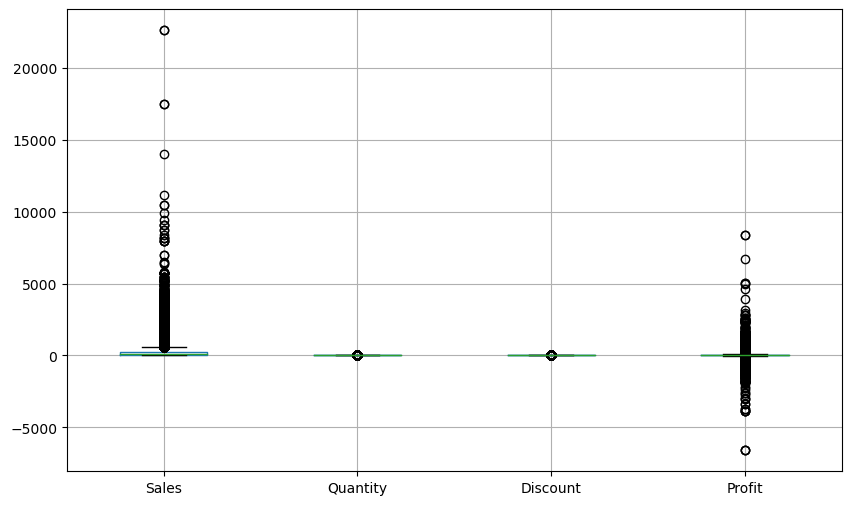

In [318]:
# Plot boxplots for numeric columns to visualize potential outliers
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
df_merged[numeric_cols].boxplot(figsize=(10, 6))
plt.show()


In [319]:
# Remove outliers using the IQR method for each numeric column
for col in numeric_cols:
    Q1 = df_merged[col].quantile(0.25)
    Q3 = df_merged[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_merged = df_merged[(df_merged[col] >= lower_bound) & (df_merged[col] <= upper_bound)]


# Q1

In [320]:
# Remove null values if any
factsales = factsales.dropna(subset=["Discount", "Quantity", "Sales", "Profit"])

In [321]:
for column in factsales.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = factsales[column].quantile(0.01)
    Q3 = factsales[column].quantile(0.99)
    IQR = Q3 - Q1                   
    lower_bound = Q1 - 1.5 * IQR   
    upper_bound = Q3 + 1.5 * IQR  
    
    factsales = factsales[(df[column] >= lower_bound) & (factsales[column] <= upper_bound)]

C:\Users\2021\AppData\Local\Temp\ipykernel_29644\139581328.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  factsales = factsales[(df[column] >= lower_bound) & (factsales[column] <= upper_bound)]
C:\Users\2021\AppData\Local\Temp\ipykernel_29644\139581328.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  factsales = factsales[(df[column] >= lower_bound) & (factsales[column] <= upper_bound)]
C:\Users\2021\AppData\Local\Temp\ipykernel_29644\139581328.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  factsales = factsales[(df[column] >= lower_bound) & (factsales[column] <= upper_bound)]


In [322]:
# Feature Engineering: Creating new relevant features
factsales["Profit Margin"] = factsales["Profit"] / factsales["Sales"]
factsales["Discount Impact"] = factsales["Discount"] * factsales["Quantity"]

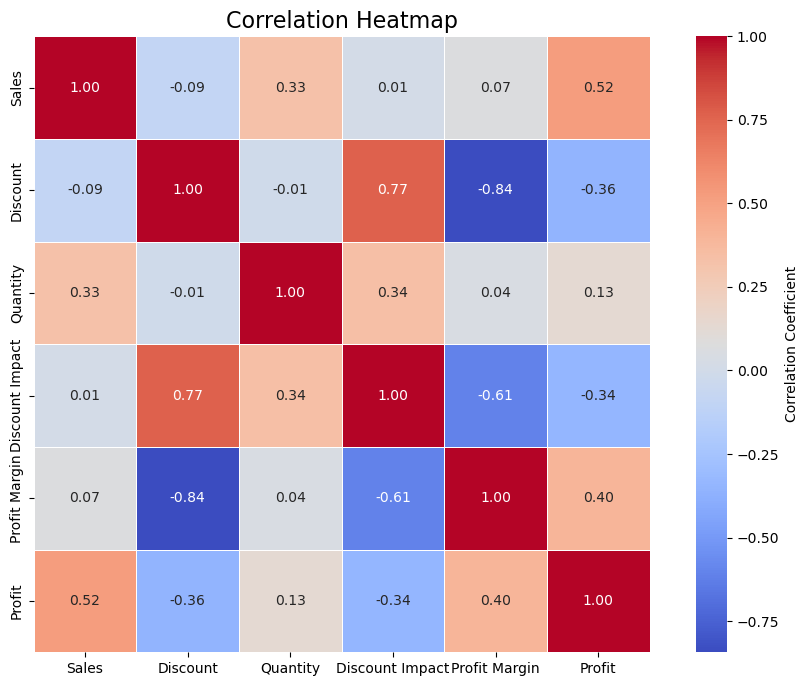

In [323]:
factsales = factsales[["Sales", "Discount", "Quantity", "Discount Impact", "Profit Margin", "Profit"]]
corr = factsales.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'}, square=True)  
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [324]:
print(factsales.shape)


(57794, 6)


In [325]:
# Selecting features for the model
features = ["Sales", "Discount", "Quantity", "Discount Impact", "Profit Margin"]
X = factsales[features]
y = factsales["Profit"]

In [326]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [327]:
# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [328]:
# Train XGBoost Regressor
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=500, learning_rate=0.3, max_depth=3, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.3, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [329]:
# Predictions
y_pred_Train = xgb_model.predict(X_train_scaled)
y_pred = xgb_model.predict(X_test_scaled)


In [330]:
# Model Evaluation
mae_tr = mean_absolute_error(y_train, y_pred_Train)
r2_tr = r2_score(y_train, y_pred_Train)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print()
print(f'for train data : mae:{mae_tr}, r2 score:{r2_tr}')
print(f'for test data : mae:{mae}, r2 score:{r2}')
print()


for train data : mae:3.162031960517256, r2 score:0.9966372551014776
for test data : mae:3.6387523138061635, r2 score:0.9931343951234353



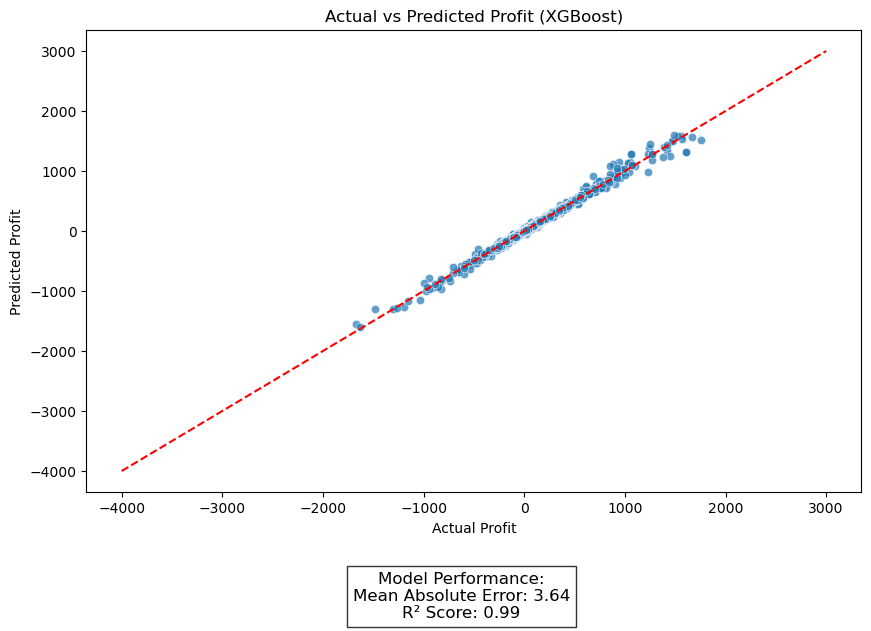

In [331]:
# Plot Actual vs Predicted Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([-4000, 3000], [-4000, 3000], linestyle='dashed', color='red')
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit (XGBoost)")

# Display Model Performance
plt.figtext(0.5, -0.1, f"Model Performance:\nMean Absolute Error: {mae:.2f}\nR² Score: {r2:.2f}", 
            fontsize=12, ha="center", bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# Q2

In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix


In [126]:
# Select numerical features for clustering
features = ['Sales', 'Quantity', 'Discount', 'Profit']
X = df_merged[features].dropna()

In [127]:
# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

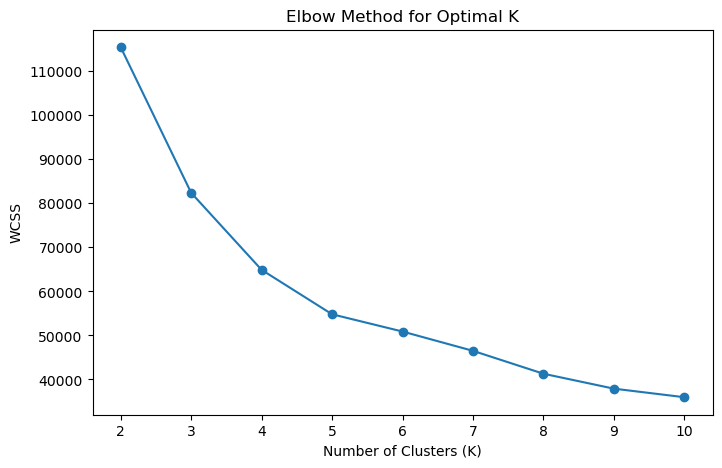

In [128]:
# Elbow Method to determine optimal K
wcss = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

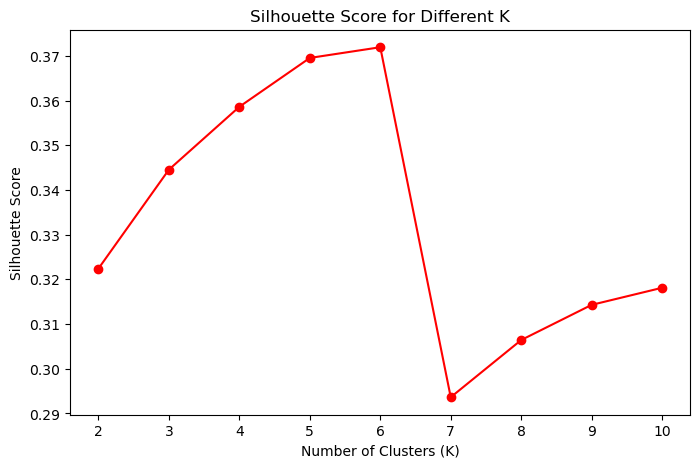

In [129]:
# Silhouette Score for different K values
sil_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, cluster_labels))

plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o', color='red')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K')
plt.show()

In [130]:
# Apply KMeans clustering with K=5
kmeans = KMeans(n_clusters=5, random_state=42)
df_merged['Cluster'] = kmeans.fit_predict(X_scaled)

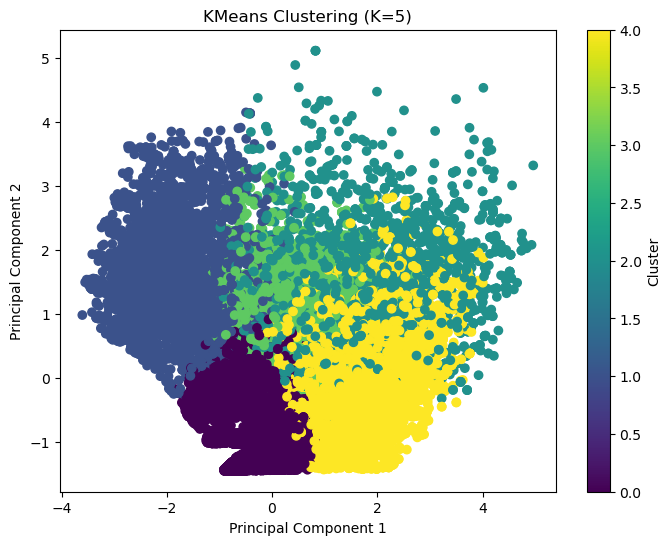

Cluster centers (in original feature space):
[[-0.45995295 -0.61213002 -0.33592998 -0.2502122 ]
 [-0.27108131  0.03886581  2.22815448 -1.26696212]
 [ 2.78912807  0.31593592  0.02425817  0.41520889]
 [-0.19674425  1.33039148 -0.27740804  0.00292086]
 [ 0.65485204  0.09156077 -0.42132207  1.66489624]]


In [132]:
# Visualize the clusters (for 2D visualization, we'll use the first two principal components)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_merged['Cluster'], cmap='viridis')
plt.title('KMeans Clustering (K=5)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

# Show cluster centers in original feature space (before PCA)
cluster_centers = kmeans.cluster_centers_
print("Cluster centers (in original feature space):")
print(cluster_centers)

In [284]:
merged = df_merged.merge(dimship, on='OrderID', how='left') \
                     .merge(dimorder, on='OrderID', how='left')

merged.head()

,SalesID,OrderID,ProductID,CustomerID_x,DateID,GeographyID,Sales,Quantity,Discount,Profit,...,ShipDate,ShipMode_y,City_y,State_y,Country_y,Region_y,CustomerID_y,OrderPriority,OrderDate,Market_y
0,1200,CA-2011-169642,OFF-ST-10002574,BB-10990,447,27,276.28,2,0.0,0.0,...,2011-07-30 00:00:00.000,Second Class,Los Angeles,California,United States,West,BB-10990,Medium,2011-07-27 00:00:00.000,US
1,1486,CA-2012-142993,OFF-ST-10000934,KA-16525,555,48,81.96,2,0.0,0.0,...,2012-10-17 00:00:00.000,Standard Class,Seattle,Washington,United States,West,KA-16525,Medium,2012-10-12 00:00:00.000,US
2,1501,CA-2012-130736,OFF-FA-10003467,JF-15490,705,48,3.96,2,0.0,0.0,...,2012-12-09 00:00:00.000,First Class,Seattle,Washington,United States,West,JF-15490,Critical,2012-12-07 00:00:00.000,US
3,2167,CA-2011-136567,OFF-ST-10004337,PS-19045,17,105,122.48,2,0.0,0.0,...,2011-12-21 00:00:00.000,First Class,Harrisonburg,Virginia,United States,South,PS-19045,High,2011-12-20 00:00:00.000,US
4,5202,AG-2011-4560,FUR-DEF-10000572,EG-3900,17,805,103.92,2,0.0,0.0,...,2011-12-27 00:00:00.000,Standard Class,Annaba,Annaba,Algeria,Africa,EG-3900,Low,2011-12-20 00:00:00.000,Africa


In [285]:
# Remove columns using the 'columns' parameter
merged = merged.drop(columns=['ShipMode_y', 'City_y', 'State_y', 'Country_y', 'Region_y', 'CustomerID_y', 'Market_y'])
merged.rename(columns={
    'Market_x': 'Market',
    'ShipMode_x': 'ShipMode',
    'City_x':'City',
    'State_x':'State',
    'Country_x' : 'Country',
    'Region_x' : 'Region'
    
}, inplace=True)


In [286]:
# Label Encoding for categorical variables
label_encoders = {}
categorical_cols = ['Category', 'SubCategory', 'Market', 'Discount Category', 'City', 'State', 'Country', 'Region']
for col in categorical_cols:
    le = LabelEncoder()
    merged[col] = le.fit_transform(merged[col])
    label_encoders[col] = le

In [ ]:
# One-Hot Encoding for Ship Mode (Target Variable)
le_shipmode = LabelEncoder()
merged['ShipMode'] = le_shipmode.fit_transform(merged['ShipMode'])


In [288]:
merged['Delivery_Duration'] = (pd.to_datetime(merged['ShipDate']) - pd.to_datetime(merged['OrderDate'])).dt.days

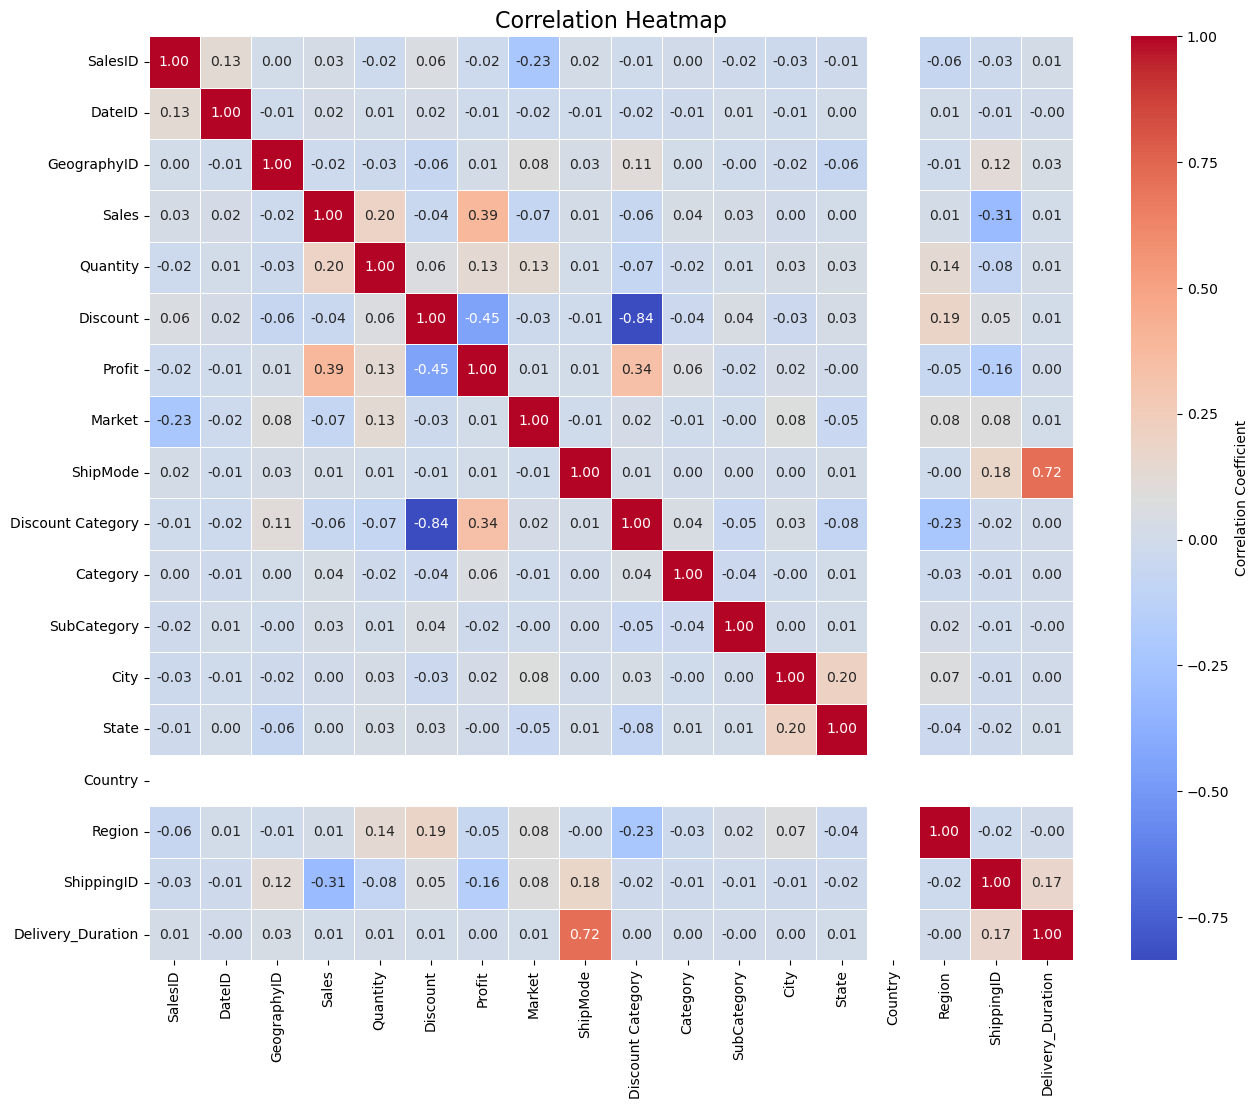

In [289]:
# Compute correlation matrix for numeric columns
corr = merged.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'}, square=True)  
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [ ]:
# Selecting features and target variable
features = ['Sales', 'Quantity', 'Discount', 'Profit', 'Category', 'SubCategory', 
            'Market',  'City', 'State', 'Region', 'Delivery_Duration']
X = merged[features]
y = merged['ShipMode']

In [252]:
# Standardizing numerical features
numeric_cols = X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])


In [206]:
# Handling imbalanced data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


c:\Users\2021\anaconda3\envs\quera\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [207]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [208]:
# Train models
rf = RandomForestClassifier(n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)


In [209]:
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [210]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

In [211]:
# Evaluate models
print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

print("Gradient Boosting Accuracy: ", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gb))


Random Forest Accuracy:  0.9137127371273712
Random Forest Classification Report:
                 precision    recall  f1-score   support

   First Class       0.89      0.92      0.91      4675
      Same Day       1.00      1.00      1.00      4651
  Second Class       0.89      0.75      0.81      4593
Standard Class       0.88      0.99      0.93      4531

      accuracy                           0.91     18450
     macro avg       0.91      0.91      0.91     18450
  weighted avg       0.91      0.91      0.91     18450

Gradient Boosting Accuracy:  0.8094308943089431
Gradient Boosting Classification Report:
                 precision    recall  f1-score   support

   First Class       0.67      0.88      0.76      4675
      Same Day       1.00      0.99      1.00      4651
  Second Class       0.75      0.37      0.49      4593
Standard Class       0.83      1.00      0.91      4531

      accuracy                           0.81     18450
     macro avg       0.81      0.81    

In [212]:
# Feature Importance
feature_importance_rf = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
feature_importance_gb = pd.DataFrame({'Feature': features, 'Importance': gb.feature_importances_})

print("\nRandom Forest Feature Importance:")
print(feature_importance_rf.sort_values(by='Importance', ascending=False))

print("\nGradient Boosting Feature Importance:")
print(feature_importance_gb.sort_values(by='Importance', ascending=False))


Random Forest Feature Importance:
              Feature  Importance
10  Delivery_Duration    0.589622
7              City_x    0.065306
1            Quantity    0.062956
0               Sales    0.062096
3              Profit    0.061216
8             State_x    0.051427
5         SubCategory    0.036557
9            Region_x    0.022714
2            Discount    0.018633
6            Market_x    0.017218
4            Category    0.012254

Gradient Boosting Feature Importance:
              Feature  Importance
10  Delivery_Duration    0.950234
1            Quantity    0.034902
7              City_x    0.006038
8             State_x    0.002558
4            Category    0.001731
3              Profit    0.001042
9            Region_x    0.000861
0               Sales    0.000852
5         SubCategory    0.000773
6            Market_x    0.000515
2            Discount    0.000494


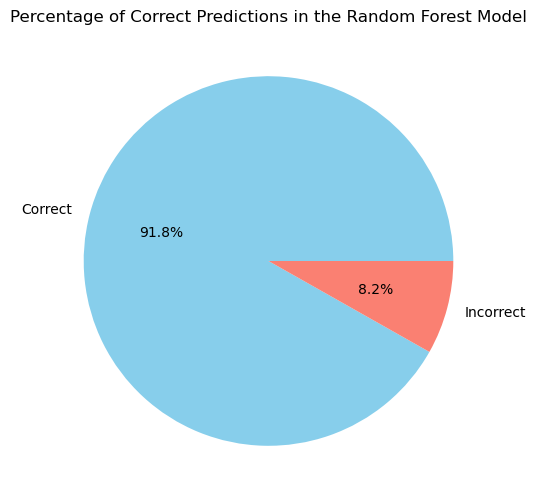

In [244]:
# Calculate the number of correct and incorrect predictions
correct = sum(y_test == y_pred_rf)
incorrect = len(y_test) - correct

# Plot a pie chart
plt.figure(figsize=(6, 6))
plt.pie([correct, incorrect], labels=["Correct", "Incorrect"], autopct="%1.1f%%", colors=["skyblue", "salmon"])
plt.title("Percentage of Correct Predictions in the Random Forest Model")
plt.show()


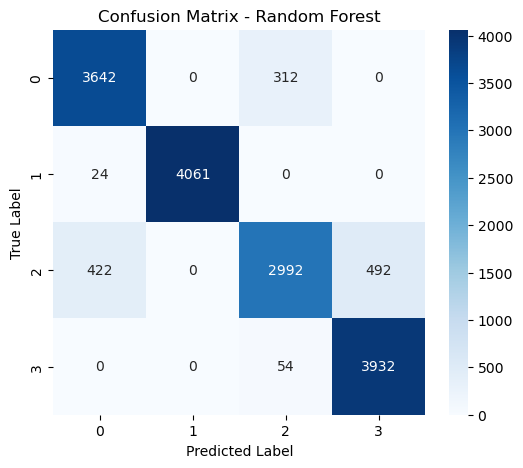

In [291]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()